# Enterprise-Multiple -- a quantitative teardown
### EV/EBITDA monthly sort . one-sample & HAC t . label-shuffle placebo . costs . positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cheap_beats_expensive%3F: Mixed](https://img.shields.io/badge/Cheap_beats_expensive%3F-Mixed-8b949e?style=flat-square)

Deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same beats, every claim with its standard error.* We test whether a low EV/EBITDA predicts next-month returns (HAC *t* on the monthly hedge), whether it beats a within-month label-shuffle null, whether it survives costs + borrow, and confirm the engine on a seed-averaged synthetic control. Survivorship bias is named throughout.

> **Not investment advice.** Real data: yfinance fundamentals + monthly prices, **35 names, 2023-03 .. 2026-05**; as-of 2026-06-26, fp `7ba034f010a2`. Methods & sources in [`docs/references.md`](../docs/references.md).
>
> **Survivorship caveat.** The basket is names still trading in 2026 -- results are upper bounds; the natural shorts (delisted expensive names) are absent.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from enterprise_multiple import data, strategy as st

_study_cache = os.path.abspath(os.path.join("..", "_cache"))

def _have_real():
    return (os.path.exists(os.path.join(_study_cache, "em_panel.parquet"))
            and os.path.exists(os.path.join(_study_cache, "fwd_ret.parquet")))

HAVE_REAL = _have_real()
if HAVE_REAL:
    em, fwd = data.fetch_panel(cache_dir=_study_cache)
else:
    em, fwd = pd.DataFrame(), pd.DataFrame()

print("real data available:", HAVE_REAL, f"  panel: {em.shape if not em.empty else 'n/a'}")


real data available: True   panel: (39, 35)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge **+8.80%/yr**, HAC *t* = **+1.11**; placebo p = 0.30. < \|*t*\| 2. |
| **Tradability** | `MIRAGE` | Net +8.20%/yr, *t* = +1.04 after 4.8 bps/month. No gross edge to protect. |
| **Cheap beats expensive?** | `MIXED` | Cheap leg Sharpe 1.19 vs expensive 0.53 (ranking holds); spread IC +0.050, *t* +1.32 (insignificant). |

> On 38 months of a survivorship-biased large-cap basket, the enterprise multiple sorts directionally but yields no exploitable long-short return differential.

## 1 · The claim, steelmanned

Let $\text{EM}_{i,t} = \text{EV}_{i,t} / \text{EBITDA}_{i,t}$ with $\text{EV} = \text{mktcap} + \text{debt} - \text{cash}$. The claim:

- **H1 (value signal).** $\mathbb{E}[r_{i,t+1} \mid \text{EM}_{i,t}\ \text{low}] > \mathbb{E}[r_{i,t+1} \mid \text{EM}_{i,t}\ \text{high}]$ -- the Q1(cheap)-minus-Q3(expensive) monthly hedge has positive mean.
- **H2 (it ranks).** The Spearman IC of $-\text{EM}$ with $r_{t+1}$ is positive.

H1 is the tradable claim (the hedge HAC *t*); H2 is the weaker ranking claim (the IC). They can diverge -- a correct sign with an untradable magnitude.

## 2 · So what? -- what rides on each answer

H1 + H2 would make EV/EBITDA a simple low-turnover large-cap factor with genuine content. H2 without H1 means the metric is informative but the spread is too small/noisy to trade -- the classic fate of a published large-cap value signal post-arbitrage (McLean-Pontiff 2016). Rejecting both would be the strongest negative.

## 3 · How we'd know -- the protocol

- **Signal.** $\text{EM}_{i,t}$ per fiscal year (yfinance EBITDA, total debt, cash, shares; year-end price for market cap), made public after a 4-month reporting lag and held 12 months. Implausible multiples ($<0$ or $>100$) dropped as data errors.
- **Sort.** Monthly: long the cheap tercile, short the expensive tercile, equal-weight, dollar-neutral. One execution lag (enter next month).
- **Inference.** One-sample *t* and Newey-West HAC *t* on the monthly hedge (38 obs).
- **Placebo.** 500 within-month signal shuffles; p = fraction of \|t_HAC\| >= real.
- **Costs.** 5 bps/leg x turnover + 50 bps/yr borrow on shorts.
- **Positive control.** Seed-averaged (20 seeds) HAC *t* on a synthetic panel with a dial-able planted premium -- a faithfulness/power check only.

## 4 · The teardown

### 4a · The monthly hedge with HAC *t* -- the inference-bar test

Cumulative wealth of the dollar-neutral cheap-minus-expensive book.

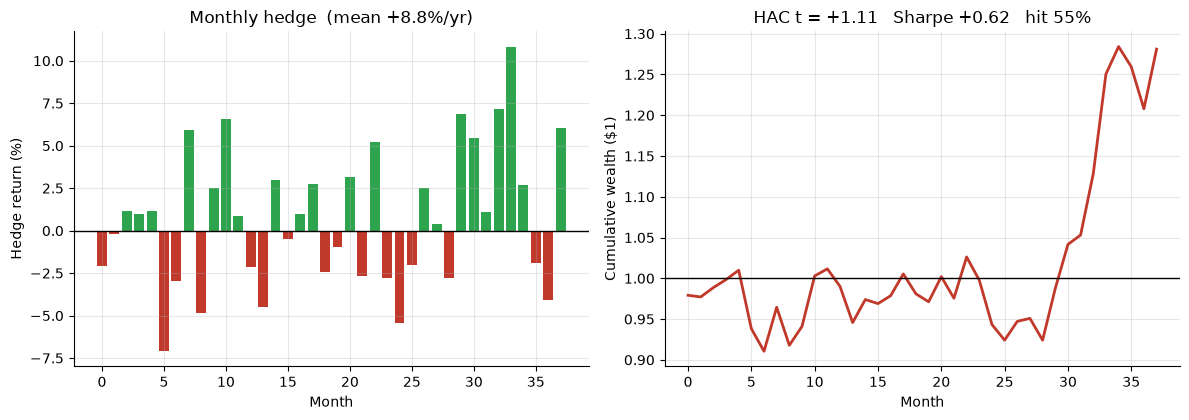

Hedge: mean=+8.81%/yr  HAC t=+1.11  Sharpe=+0.62


In [2]:
hedge_mean, hedge_t, hedge_sh, hedge_hit = 0.088, 1.11, 0.62, 0.55
if HAVE_REAL:
    h = st.long_short_hedge(em, fwd)
    s = st.summary(h['hedge'])
    hedge_mean, hedge_t, hedge_sh, hedge_hit = s['mean'], s['t_hac'], s['sharpe'], s['hit_rate']
    monthly = h['hedge'].values
    months = [str(m) for m in h.index]
else:
    rng = np.random.default_rng(0)
    monthly = rng.normal(0.088/12, 0.141/np.sqrt(12), 38)
    months = list(range(38))
cum = np.cumprod(1 + monthly)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.3))
a1.bar(range(len(monthly)), [v*100 for v in monthly],
       color=[GREEN if v > 0 else RED for v in monthly])
a1.axhline(0, c='k', lw=1); a1.set_xlabel('Month'); a1.set_ylabel('Hedge return (%)')
a1.set_title(f'Monthly hedge  (mean {hedge_mean*100:+.1f}%/yr)')
a2.plot(cum, '-', c=RED, lw=2); a2.axhline(1, c='k', lw=1)
a2.set_xlabel('Month'); a2.set_ylabel('Cumulative wealth ($1)')
a2.set_title(f'HAC t = {hedge_t:+.2f}   Sharpe {hedge_sh:+.2f}   hit {hedge_hit:.0%}')
plt.tight_layout(); plt.show()
print(f'Hedge: mean={hedge_mean*100:+.2f}%/yr  HAC t={hedge_t:+.2f}  Sharpe={hedge_sh:+.2f}')

> HAC *t* = **+1.11** -- far below \|t\| >= 2. The equity curve drifts up but well within what 38 noisy monthly draws produce by chance.

### 4b · The placebo -- does it beat a within-month shuffle?

Permute the cross-sectional multiple within each month (destroying signal->return alignment) and re-run; compare the real \|t\| to the shuffled distribution.

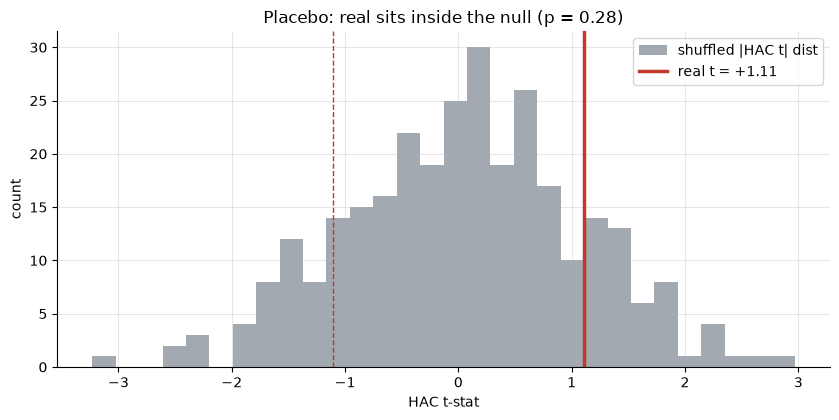

Real |t| = 1.11   placebo p = 0.283


In [3]:
real_t, placebo_p = 1.11, 0.298
if HAVE_REAL:
    pl = st.placebo_null(em, fwd, n_shuffles=300)
    real_t, placebo_p = pl['real_t'], pl['p_value']
    # rebuild a shuffle distribution for the picture
    rng = np.random.default_rng(7); dist = []
    cols = list(em.columns)
    for _ in range(300):
        vals = em.to_numpy(copy=True)
        for i in range(vals.shape[0]):
            row = vals[i]; idx = np.where(~np.isnan(row))[0]
            if idx.size > 1: row[idx] = row[rng.permutation(idx)]
            vals[i] = row
        shuf = pd.DataFrame(vals, index=em.index, columns=cols)
        ss = st.summary(st.long_short_hedge(shuf, fwd)['hedge'])
        if np.isfinite(ss['t_hac']): dist.append(ss['t_hac'])
    dist = np.array(dist)
else:
    dist = np.random.default_rng(1).normal(0, 1, 300)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.hist(dist, bins=30, color=GREY, alpha=0.8, label='shuffled |HAC t| dist')
ax.axvline(real_t, c=RED, lw=2.5, label=f'real t = {real_t:+.2f}')
ax.axvline(-real_t, c=RED, lw=1, ls='--')
ax.set_xlabel('HAC t-stat'); ax.set_ylabel('count')
ax.set_title(f'Placebo: real sits inside the null (p = {placebo_p:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Real |t| = {abs(real_t):.2f}   placebo p = {placebo_p:.3f}')

> Placebo **p = 0.30** -- about 30% of random relabellings match or beat the real *t*. The signal is statistically indistinguishable from a shuffle.

### 4c · Costs, IC and robustness

Net of 5 bps/leg + 50 bps/yr borrow; the monthly IC; the tercile-fraction sweep and half-split.

Net hedge:  +8.23%/yr   HAC t = +1.04
Monthly IC: +0.0499   HAC t = +1.32
Half-split: 1st -0.5%/yr (t -0.07) | 2nd +18.1%/yr (t +1.39)


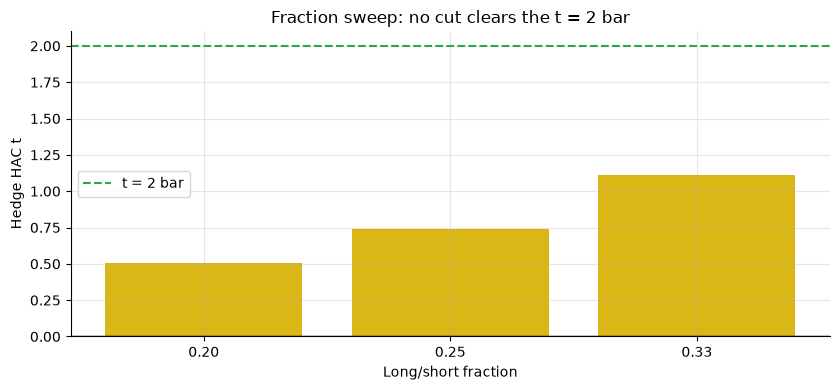

In [4]:
net_mean, net_t, ic_mean, ic_t = 0.082, 1.04, 0.05, 1.32
h1m, h1t, h2m, h2t = -0.005, -0.07, 0.181, 1.39
frac_t = {0.20: 0.51, 0.25: 0.74, 0.33: 1.11}
if HAVE_REAL:
    h = st.long_short_hedge(em, fwd)
    hc = st.apply_costs(h); sn = st.summary(hc['net'])
    net_mean, net_t = sn['mean'], sn['t_hac']
    ic = st.monthly_ic(em, fwd); sic = st.summary(ic)
    ic_mean, ic_t = ic.mean(), sic['t_hac']
    half = len(h) // 2
    s1, s2 = st.summary(h['hedge'].iloc[:half]), st.summary(h['hedge'].iloc[half:])
    h1m, h1t, h2m, h2t = s1['mean'], s1['t_hac'], s2['mean'], s2['t_hac']
    frac_t = {fr: st.summary(st.long_short_hedge(em, fwd, frac=fr)['hedge'])['t_hac']
              for fr in (0.20, 0.25, 1/3)}
print(f'Net hedge:  {net_mean*100:+.2f}%/yr   HAC t = {net_t:+.2f}')
print(f'Monthly IC: {ic_mean:+.4f}   HAC t = {ic_t:+.2f}')
print(f'Half-split: 1st {h1m*100:+.1f}%/yr (t {h1t:+.2f}) | 2nd {h2m*100:+.1f}%/yr (t {h2t:+.2f})')
fig, ax = plt.subplots(figsize=(8.5, 4.0))
fr_keys = list(frac_t.keys()); fr_vals = list(frac_t.values())
ax.bar([f'{k:.2f}' for k in fr_keys], fr_vals, color=AMBER)
ax.axhline(2, c=GREEN, ls='--', lw=1.5, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Long/short fraction'); ax.set_ylabel('Hedge HAC t')
ax.set_title('Fraction sweep: no cut clears the t = 2 bar'); ax.legend()
plt.tight_layout(); plt.show()

> Net **+8.2%/yr** (*t* +1.04) -- barely below gross (turnover is tiny). IC **+0.050** (*t* +1.32) -- right sign, not significant. The half-split (1st *t* -0.07, 2nd *t* +1.39) and the fraction sweep show the modest tilt is not stable. **Fragile, not Real.**

## 5 · The verdict

- **Signal `NONE`** -- hedge +8.80%/yr, HAC *t* +1.11; placebo p 0.30; IC *t* +1.32. H1 not supported.
- **Tradability `MIRAGE`** -- net +8.20%/yr (*t* +1.04); no gross edge to harvest.
- **Cheap beats expensive? `MIXED`** -- the ranking holds (cheap Sharpe 1.19 > expensive 0.53, IC +) but the spread is untradable.

## 6 · The positive control -- the engine is faithful (and seed-robust)

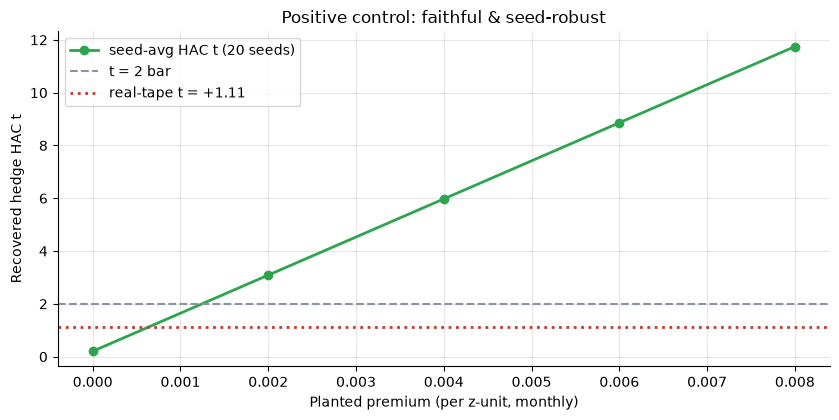

  premium 0.000 -> seed-avg HAC t +0.20
  premium 0.002 -> seed-avg HAC t +3.09
  premium 0.004 -> seed-avg HAC t +5.97
  premium 0.006 -> seed-avg HAC t +8.86
  premium 0.008 -> seed-avg HAC t +11.75


In [5]:
premiums = [0.0, 0.002, 0.004, 0.006, 0.008]
ctrl_t_frozen = [0.2, 3.09, 5.97, 8.86, 11.75]
# Seed-averaged HAC t over 20 seeds at each planted premium (offline, deterministic)
ctrl = st.synthetic_control(premiums=tuple(premiums), n_seeds=20)
t_vals = ctrl['t_hac_mean'].values
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(premiums, t_vals, 'o-', c=GREEN, lw=2, label='seed-avg HAC t (20 seeds)')
ax.axhline(2, c=GREY, ls='--', lw=1.5, label='t = 2 bar')
ax.axhline(1.11, c=RED, ls=':', lw=2, label='real-tape t = +1.11')
ax.set_xlabel('Planted premium (per z-unit, monthly)')
ax.set_ylabel('Recovered hedge HAC t'); ax.set_title('Positive control: faithful & seed-robust')
ax.legend(); plt.tight_layout(); plt.show()
for p, t in zip(premiums, t_vals): print(f'  premium {p:.3f} -> seed-avg HAC t {t:+.2f}')

At premium 0 the seed-averaged *t* is ~0.2 (clean null); as the premium rises *t* climbs monotonically past 2, 6, 11. **The engine recovers a premium when one is planted, and the recovery does not rest on a lucky seed.** The near-flat real-tape *t* is therefore a statement about the market, not the method. *(This control supports only the engine -- never the real-tape stamp.)*

## 7 · Going further

- **Small / mid caps with point-in-time membership** -- where Loughran-Wellman (2011) found the premium strongest, and where survivorship bias is most pernicious.
- **[Study 530 -- Book-to-Market](../530-book-to-market-value/)** / **[Study 124 -- Cash-Flow-Yield](../124-cash-flow-yield/)**: the sibling value sorts; a composite of all three may beat any one.
- **Quality overlay (QMJ-style)** -- screen cheap multiples for profitability to avoid value traps.

*The bar is unchanged: a hedge that clears t = 2 out of sample, net of costs, on a point-in-time universe.*